In [1]:
# importing required libraries and modules
import numpy as np 
import re
import nltk 
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from wordcloud import WordCloud
from pylab import rcParams
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,f1_score,recall_score,precision_score
import pickle

In [2]:
#Load the Reviews.csv dataset
df1 = pd.read_csv("C:/Users/dell/Desktop/Dissertation/Google Play Store Apps Reviews (+110K Comment)/Reviews.csv")
df1.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,app_Id
0,gp:AOqpTOHfSfVMoxl5cmq9kUks-tT3nXBdyWPRhKlms5M...,Laaonnoi Jaiyod,https://lh3.googleusercontent.com/a-/AOh14Gjrz...,Very laggy when chatting with latest version u...,1.0,0.0,10.3.1,2020-03-11 01:11:24,NaN,NaN,com.PepiPlay.KingsCastle
1,gp:AOqpTOHwTEuUGKuBJHgKtC60SVIAOUCWRNTlMPkIbmP...,Capp Farmer,https://lh3.googleusercontent.com/-1RlCo0f43Ko...,Its amazing....i like it very much...this app ...,5.0,2.0,NaN,2019-11-05 03:15:59,NaN,NaN,ginlemon.smartlauncher.extratool
2,gp:AOqpTOEb89oAwK_PlbgxA1rMHeYt9ntF76UuEhdPgjc...,Sandeep Sawant,https://lh3.googleusercontent.com/a-/AOh14Gi7R...,Good one,4.0,0.0,1.4.6,2018-08-28 18:19:49,NaN,NaN,tv.twitch.android.app
3,gp:AOqpTOFogWYVbXl8ZeE7K3YoN_sDWRr20jOO16Oarlk...,Tomas Šakalys,https://lh3.googleusercontent.com/a-/AOh14GjWU...,The only app that worked for my 2004 Renaul Cl...,5.0,1.0,1.41.7,2019-12-06 17:14:08,NaN,NaN,homeworkout.homeworkouts.noequipment
4,gp:AOqpTOFxlcucPGyAhbpEZH676xCB-px8kHoTWP3BY-2...,Michael,https://lh3.googleusercontent.com/a-/AOh14Gibm...,I like the start up and instant on.,5.0,0.0,2.3,2016-10-21 15:35:18,NaN,NaN,com.houzz.app


In [3]:
#Load the Apps.csv dataset
df2 = pd.read_csv("C:/Users/dell/Desktop/Dissertation/Google Play Store Apps Reviews (+110K Comment)/Apps.csv")
df2.head()

,appId,url,adSupported,containsAds,released,title,score,reviews,price,free,genre,ratings,installs,size,contentRating,contentRatingDescription
0,com.iqoption,https://play.google.com/store/apps/details?id=...,NaN,NaN,NaN,IQ Option – Online Investing Platform,3.950087,180508.0,0.00,True,Finance,447684.0,"50,000,000+",30M,Everyone,NaN
1,com.jaumo.casual,https://play.google.com/store/apps/details?id=...,True,True,"Oct 6, 2017",Joyride – Open-Minded Dating & Passionate Singles,4.323741,77062.0,0.00,True,Dating,195161.0,"10,000,000+",16M,Mature 17+,NaN
2,de.elfsoft.bestbrokers,https://play.google.com/store/apps/details?id=...,True,True,"Oct 4, 2015",Best Brokers: Stock Simulator,4.393720,4875.0,0.00,True,Finance,16631.0,"1,000,000+",6.0M,Everyone,NaN
3,com.propagator.squeezy,https://play.google.com/store/apps/details?id=...,NaN,NaN,"Nov 24, 2014",Squeezy: NHS Pelvic Floor App,4.726829,1024.0,3.99,False,Medical,2064.0,"50,000+",Varies with device,Everyone,NaN
4,com.Slack,https://play.google.com/store/apps/details?id=...,NaN,NaN,"Jul 22, 2013",Slack,4.176385,15010.0,0.00,True,Business,77934.0,"10,000,000+",Varies with device,Everyone,NaN


# Data exploration

In [4]:
#Number of rows and columns of Reviews dataset
df1.shape

(114344, 11)

In [5]:
#Summary of reviews dataframe
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114344 entries, 0 to 114343
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   reviewId              114344 non-null  object 
 1   userName              114344 non-null  object 
 2   userImage             114344 non-null  object 
 3   content               114301 non-null  object 
 4   score                 114344 non-null  float64
 5   thumbsUpCount         114344 non-null  float64
 6   reviewCreatedVersion  99946 non-null   object 
 7   at                    114344 non-null  object 
 8   replyContent          16104 non-null   object 
 9   repliedAt             16104 non-null   object 
 10  app_Id                114344 non-null  object 
dtypes: float64(2), object(9)
memory usage: 9.6+ MB


In [6]:
#Check number of missing values of Reviews dataset
print(df1.isnull().sum())

reviewId                    0
userName                    0
userImage                   0
content                    43
score                       0
thumbsUpCount               0
reviewCreatedVersion    14398
at                          0
replyContent            98240
repliedAt               98240
app_Id                      0
dtype: int64


In [7]:
#Number of rows and columns of Apps dataset
df2.shape

(161, 16)

In [8]:
#Summary of Apps dataframe
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appId                     161 non-null    object 
 1   url                       161 non-null    object 
 2   adSupported               102 non-null    object 
 3   containsAds               102 non-null    object 
 4   released                  152 non-null    object 
 5   title                     161 non-null    object 
 6   score                     160 non-null    float64
 7   reviews                   160 non-null    float64
 8   price                     161 non-null    float64
 9   free                      161 non-null    bool   
 10  genre                     161 non-null    object 
 11  ratings                   160 non-null    float64
 12  installs                  161 non-null    object 
 13  size                      161 non-null    object 
 14  contentRat

In [9]:
#Check number of missing values of Apps dataset
print(df2.isnull().sum())

appId                         0
url                           0
adSupported                  59
containsAds                  59
released                      9
title                         0
score                         1
reviews                       1
price                         0
free                          0
genre                         0
ratings                       1
installs                      0
size                          0
contentRating                 0
contentRatingDescription    137
dtype: int64


In [10]:
df1 = df1.dropna(how='any', subset=['content'])

In [11]:
print(df1.isnull().sum())

reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion    14393
at                          0
replyContent            98197
repliedAt               98197
app_Id                      0
dtype: int64


In [12]:
df1 = df1.dropna(how='any', subset=['reviewCreatedVersion'])

In [13]:
print(df1.isnull().sum())

reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion        0
at                          0
replyContent            86307
repliedAt               86307
app_Id                      0
dtype: int64


In [14]:
df1.drop(["replyContent", "repliedAt"], axis = 1, inplace = True)

In [15]:
print(df1.isnull().sum())

reviewId                0
userName                0
userImage               0
content                 0
score                   0
thumbsUpCount           0
reviewCreatedVersion    0
at                      0
app_Id                  0
dtype: int64


In [16]:
df1.shape

(99908, 9)

In [17]:
df2 = df2.drop(["score"], axis = 1)

In [18]:
df2 = df2.rename(columns={'appId': 'app_Id'})

In [19]:
df2.head()

,app_Id,url,adSupported,containsAds,released,title,reviews,price,free,genre,ratings,installs,size,contentRating,contentRatingDescription
0,com.iqoption,https://play.google.com/store/apps/details?id=...,NaN,NaN,NaN,IQ Option – Online Investing Platform,180508.0,0.00,True,Finance,447684.0,"50,000,000+",30M,Everyone,NaN
1,com.jaumo.casual,https://play.google.com/store/apps/details?id=...,True,True,"Oct 6, 2017",Joyride – Open-Minded Dating & Passionate Singles,77062.0,0.00,True,Dating,195161.0,"10,000,000+",16M,Mature 17+,NaN
2,de.elfsoft.bestbrokers,https://play.google.com/store/apps/details?id=...,True,True,"Oct 4, 2015",Best Brokers: Stock Simulator,4875.0,0.00,True,Finance,16631.0,"1,000,000+",6.0M,Everyone,NaN
3,com.propagator.squeezy,https://play.google.com/store/apps/details?id=...,NaN,NaN,"Nov 24, 2014",Squeezy: NHS Pelvic Floor App,1024.0,3.99,False,Medical,2064.0,"50,000+",Varies with device,Everyone,NaN
4,com.Slack,https://play.google.com/store/apps/details?id=...,NaN,NaN,"Jul 22, 2013",Slack,15010.0,0.00,True,Business,77934.0,"10,000,000+",Varies with device,Everyone,NaN


In [20]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   app_Id                    161 non-null    object 
 1   url                       161 non-null    object 
 2   adSupported               102 non-null    object 
 3   containsAds               102 non-null    object 
 4   released                  152 non-null    object 
 5   title                     161 non-null    object 
 6   reviews                   160 non-null    float64
 7   price                     161 non-null    float64
 8   free                      161 non-null    bool   
 9   genre                     161 non-null    object 
 10  ratings                   160 non-null    float64
 11  installs                  161 non-null    object 
 12  size                      161 non-null    object 
 13  contentRating             161 non-null    object 
 14  contentRat

In [21]:
df2 = df2[['app_Id','url','title','free','genre']]
print(df2)

                                                app_Id  \
0                                         com.iqoption   
1                                     com.jaumo.casual   
2                               de.elfsoft.bestbrokers   
3                               com.propagator.squeezy   
4                                            com.Slack   
..                                                 ...   
156                                    com.sega.sprint   
157                                  net.lovoo.android   
158                 com.graph.weather.forecast.channel   
159                                 com.and.wareternal   
160  com.famousringtones2017.topringtones2017.funny...   

                                                   url  \
0    https://play.google.com/store/apps/details?id=...   
1    https://play.google.com/store/apps/details?id=...   
2    https://play.google.com/store/apps/details?id=...   
3    https://play.google.com/store/apps/details?id=...   
4    https://

In [22]:
df = pd.merge(df1,df2,on='app_Id',how = "inner")

In [23]:
df.to_csv (r'C:/Users/dell/Desktop/Dissertation/App_Reviews.csv', index = False, header=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99908 entries, 0 to 99907
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              99908 non-null  object 
 1   userName              99908 non-null  object 
 2   userImage             99908 non-null  object 
 3   content               99908 non-null  object 
 4   score                 99908 non-null  float64
 5   thumbsUpCount         99908 non-null  float64
 6   reviewCreatedVersion  99908 non-null  object 
 7   at                    99908 non-null  object 
 8   app_Id                99908 non-null  object 
 9   url                   99908 non-null  object 
 10  title                 99908 non-null  object 
 11  free                  99908 non-null  bool   
 12  genre                 99908 non-null  object 
dtypes: bool(1), float64(2), object(10)
memory usage: 10.0+ MB


In [25]:
df.shape

(99908, 13)

In [26]:
df.describe()

,score,thumbsUpCount
count,99908.000000,99908.000000
mean,3.871242,9.187112
std,1.545269,86.595437
min,1.000000,0.000000
25%,3.000000,0.000000
50%,5.000000,0.000000
75%,5.000000,2.000000
max,5.000000,9342.000000


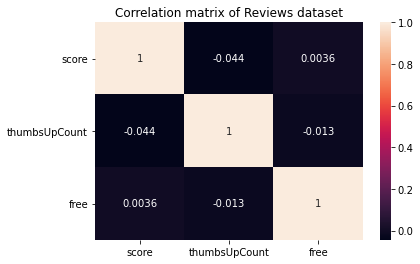

In [27]:
#Correlation Matrix to find relation among variables
corrMatrix = df.corr()
sns.heatmap(corrMatrix, annot=True)
plt.title('Correlation matrix ofa Reviews dataset', size = 12)
plt.show()

Text(0.5, 0, 'review score')

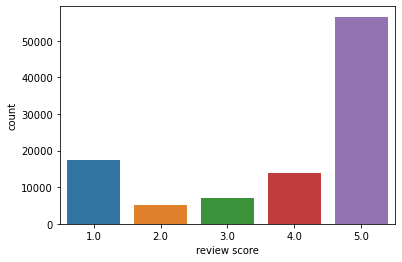

In [28]:
sns.countplot(df.score)
plt.xlabel("review score")

In [29]:
def to_sent(rating):
  rating = int(rating)
  if rating <= 2:
    return 0
  elif rating == 3:
    return 1
  else: 
    return 2

In [30]:
df['sentiment'] = df.score.apply(to_sent)

In [31]:
category_names = ['negative', 'neutral', 'positive']

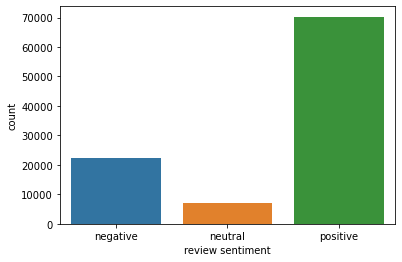

In [32]:
ax = sns.countplot(df.sentiment)
plt.xlabel('review sentiment')
ax.set_xticklabels(category_names);

In [33]:
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,app_Id,url,title,free,genre,sentiment
0,gp:AOqpTOHfSfVMoxl5cmq9kUks-tT3nXBdyWPRhKlms5M...,Laaonnoi Jaiyod,https://lh3.googleusercontent.com/a-/AOh14Gjrz...,Very laggy when chatting with latest version u...,1.0,0.0,10.3.1,2020-03-11 01:11:24,com.PepiPlay.KingsCastle,https://play.google.com/store/apps/details?id=...,Pepi Wonder World,True,Educational,0
1,gp:AOqpTOHZe5YBsVaesDyVUfMvk2drtTYOTCgWgZIbSov...,Evan Kim,https://lh3.googleusercontent.com/a-/AOh14GisG...,extremely laggy after the last update.,1.0,0.0,10.3.1,2020-03-09 23:11:51,com.PepiPlay.KingsCastle,https://play.google.com/store/apps/details?id=...,Pepi Wonder World,True,Educational,0
2,gp:AOqpTOHc5xggN-YN60VlHrEVZGJAFFLXYa4eXh66bln...,หนูแป้ง ตัวกลม,https://lh3.googleusercontent.com/a-/AOh14Gg2N...,after update too lag and delay when typing see...,1.0,1.0,10.3.1,2020-03-06 01:46:17,com.PepiPlay.KingsCastle,https://play.google.com/store/apps/details?id=...,Pepi Wonder World,True,Educational,0
3,gp:AOqpTOFh2yGz3R4VkYtwHfrpmOquY-XvNi-uV-PAM30...,red jagger,https://lh3.googleusercontent.com/-Nm-rCZWmNFA...,The app becomes hanging alot and it is annoyin...,1.0,0.0,10.3.1,2020-03-05 19:40:00,com.PepiPlay.KingsCastle,https://play.google.com/store/apps/details?id=...,Pepi Wonder World,True,Educational,0
4,gp:AOqpTOF308bScJYTuimSESeqKOS3N2GsHdt8a5QtBYL...,Vy Pagna,https://lh3.googleusercontent.com/a-/AOh14Gi98...,I really like to use Line. but since I changed...,4.0,4.0,10.1.1,2020-02-14 09:15:46,com.PepiPlay.KingsCastle,https://play.google.com/store/apps/details?id=...,Pepi Wonder World,True,Educational,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99903,gp:AOqpTOGcKjtb8dC2fOvXvphfdPCOKA6nfgS9qNIhgfU...,Boris Grandic,https://lh3.googleusercontent.com/a-/AOh14GgNM...,Very easy to use and lots of editing tools...,5.0,0.0,8.1.1,2020-05-15 20:50:56,com.quvideo.xiaoying,https://play.google.com/store/apps/details?id=...,Video Editor & Video Maker - VivaVideo,True,Video Players & Editors,2
99904,gp:AOqpTOFP0M03t3FCR9uVUzQIANTvYwgu555PqzH-mfc...,Russell,https://lh3.googleusercontent.com/-7IVrpHwhEb4...,last update made all the numbers barely visibl...,3.0,12.0,10.0.01.11,2019-04-11 19:33:28,com.quvideo.xiaoying,https://play.google.com/store/apps/details?id=...,Video Editor & Video Maker - VivaVideo,True,Video Players & Editors,1
99905,gp:AOqpTOFIc4AQ3ajbmUF6v3mguZyhWan7rinjoQYE0Nh...,Amber Duet,https://lh3.googleusercontent.com/-Ue1u37NVg4A...,I can't see the buttons now. background color ...,2.0,3.0,10.0.01.11,2019-04-06 13:33:09,com.quvideo.xiaoying,https://play.google.com/store/apps/details?id=...,Video Editor & Video Maker - VivaVideo,True,Video Players & Editors,0
99906,gp:AOqpTOHJazlugPsObMPmJKeLx2gjgCVTYS21tUgvYsl...,Harsh Verma,https://lh3.googleusercontent.com/a-/AOh14GgEN...,smooth working Calculator app by Samsung plus ...,5.0,8.0,10.0.01.11,2019-04-28 14:45:28,com.quvideo.xiaoying,https://play.google.com/store/apps/details?id=...,Video Editor & Video Maker - VivaVideo,True,Video Players & Editors,2


In [34]:
df.shape

(99908, 14)

In [35]:
print(df['title'].nunique())

153


In [36]:
df.title.value_counts()

TamTam Messenger - free chats & video calls      750
Ocean HD                                         750
Floor Plan Creator                               750
Yammer                                           750
GO Keyboard - Cute Emojis, Themes and GIFs       750
                                                ... 
Gboard - the Google Keyboard                     376
Mars: Mars                                       345
Google News: Top World & Local News Headlines    344
IP Pro(VR Cam, EseeCloud)                        180
KartRider Rush+                                  105
Name: title, Length: 153, dtype: int64

In [37]:
print(df['genre'].nunique())

40


In [38]:
print(df['genre'].unique())

['Educational' 'Entertainment' 'Health & Fitness' 'House & Home' 'Dating'
 'Role Playing' 'Sports' 'Music & Audio' 'Tools' 'Social' 'Education'
 'Weather' 'Finance' 'Art & Design' 'Shopping' 'Photography' 'Events'
 'Productivity' 'Lifestyle' 'Auto & Vehicles' 'Communication' 'Business'
 'Puzzle' 'Parenting' 'Beauty' 'Libraries & Demo' 'Action' 'Medical'
 'Video Players & Editors' 'Personalization' 'Maps & Navigation' 'Arcade'
 'Word' 'Books & Reference' 'Comics' 'Simulation' 'Casual' 'Board'
 'News & Magazines' 'Racing']


In [39]:
!pip install plotly

In [40]:
import plotly
plotly.offline.init_notebook_mode(connected=True)
import plotly.graph_objs as go

# Print the total number of unique categories
num_gencat = len(df['genre'].unique())
print('Number of categories = ', num_gencat)

# Count the number of apps in each 'Category' and sort them in descending order
num_apps_in_category = df['genre'].value_counts().sort_values(ascending =False)

data = [go.Bar(
        x = num_apps_in_category.index, # index = category name
        y = num_apps_in_category.values, # value = count
)]

plotly.offline.iplot(data)

Number of categories =  40


Text(0.5, 1.0, 'Number of Comments in each genre')

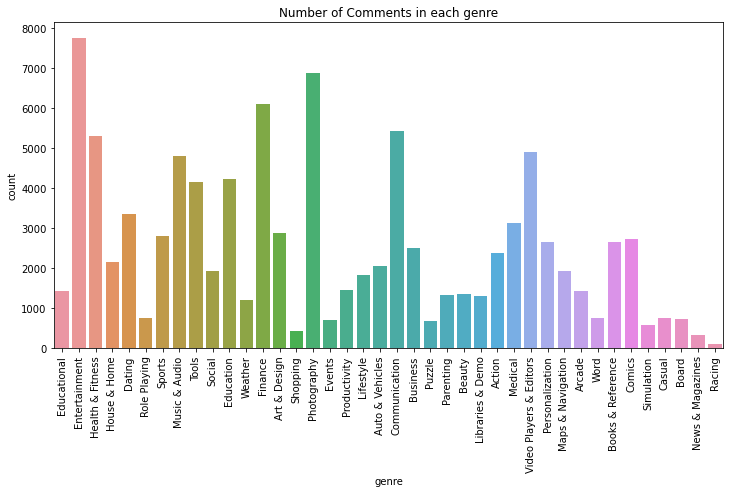

In [41]:
plt.rcParams['figure.figsize'] = (12, 6)
count_graph = sns.countplot(df['genre'])
count_graph.set_xticklabels(count_graph.get_xticklabels(),rotation=90)
count_graph
plt.title('Number of Comments in each genre', size = 12)

[Text(0.5, 0, 'Number of Postive comments'), Text(0, 0.5, 'App names')]

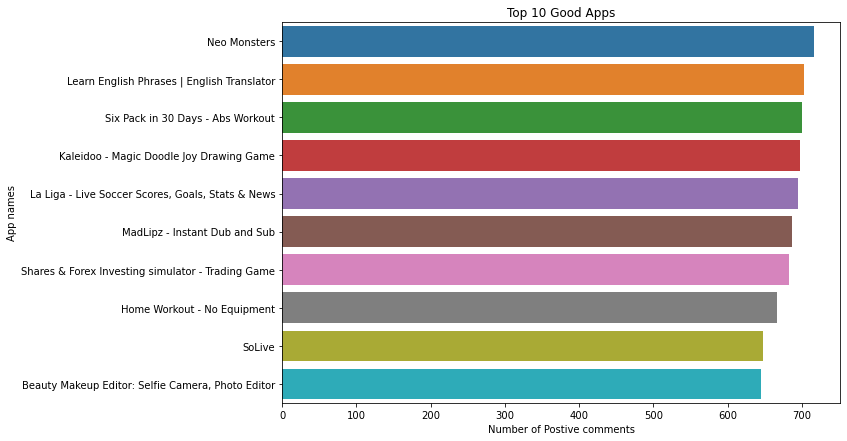

In [42]:
## Best App
plt.figure(figsize=(10,7))
best_app = df.title[df['sentiment'] == 2].value_counts().head(10)
plt.title('Top 10 Good Apps')
ax = sns.barplot(x=best_app, y=best_app.index, data=df)
ax.set(xlabel="Number of Postive comments", ylabel = "App names")

[Text(0.5, 0, 'Number of Negative comments'), Text(0, 0.5, 'App names')]

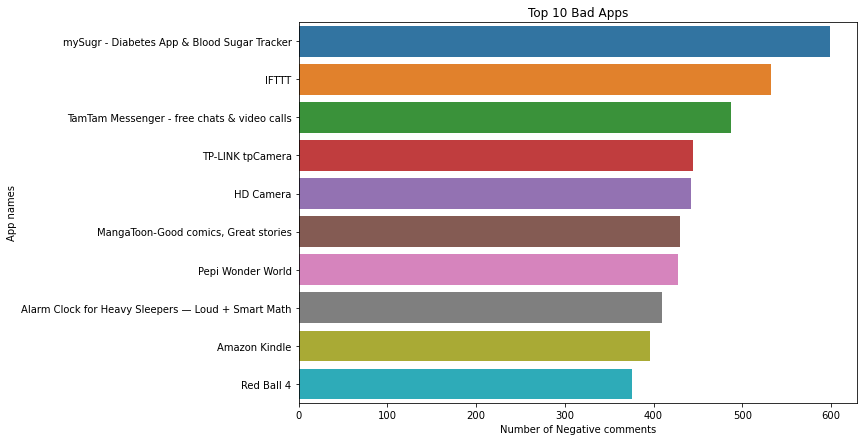

In [43]:
## Worst App
plt.figure(figsize=(10,7))
worst_app = df.title[df['sentiment'] == 0].value_counts().head(10)
plt.title('Top 10 Bad Apps')
ax = sns.barplot(x=worst_app, y=worst_app.index, data=df)
ax.set(xlabel="Number of Negative comments", ylabel = "App names")

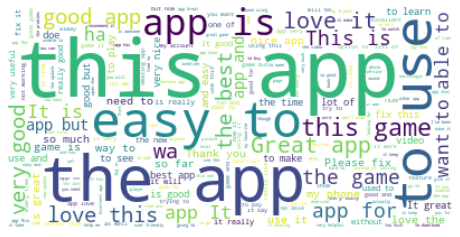

In [44]:
#df['content'] = df['content'].decode('utf-8')
text = " ".join([x for x in df.content])

wordcloud = WordCloud(background_color='white').generate(text)

plt.figure(figsize=(8,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

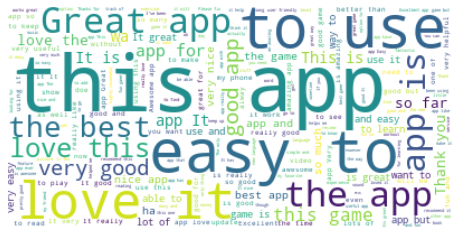

In [45]:
#positive
text = " ".join([x for x in df.content[df.sentiment==2]])

wordcloud = WordCloud(background_color='white').generate(text)

plt.figure(figsize=(8,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

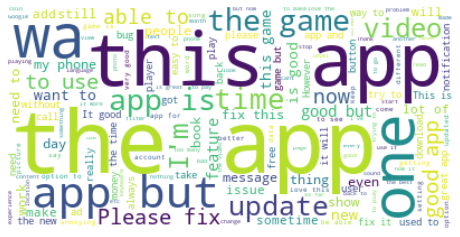

In [46]:
#neutral
text = " ".join([x for x in df.content[df.sentiment==1]])

wordcloud = WordCloud(background_color='white').generate(text)

plt.figure(figsize=(8,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

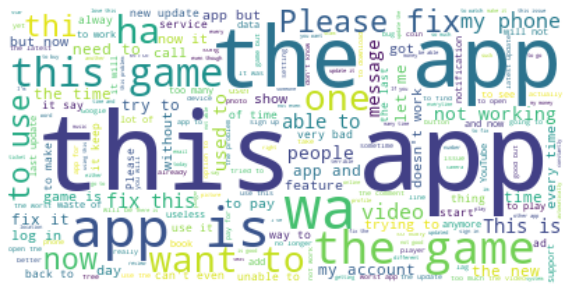

In [47]:
#negative
text = " ".join([x for x in df.content[df.sentiment==0]])

wordcloud = WordCloud(background_color='white').generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()

In [48]:
df.sentiment.value_counts()

2    70289
0    22441
1     7178
Name: sentiment, dtype: int64

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99908 entries, 0 to 99907
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   reviewId              99908 non-null  object 
 1   userName              99908 non-null  object 
 2   userImage             99908 non-null  object 
 3   content               99908 non-null  object 
 4   score                 99908 non-null  float64
 5   thumbsUpCount         99908 non-null  float64
 6   reviewCreatedVersion  99908 non-null  object 
 7   at                    99908 non-null  object 
 8   app_Id                99908 non-null  object 
 9   url                   99908 non-null  object 
 10  title                 99908 non-null  object 
 11  free                  99908 non-null  bool   
 12  genre                 99908 non-null  object 
 13  sentiment             99908 non-null  int64  
dtypes: bool(1), float64(2), int64(1), object(10)
memory usage: 13.3+ MB


In [50]:
df.describe()

,score,thumbsUpCount,sentiment
count,99908.000000,99908.000000,99908.000000
mean,3.871242,9.187112,1.478921
std,1.545269,86.595437,0.835940
min,1.000000,0.000000,0.000000
25%,3.000000,0.000000,1.000000
50%,5.000000,0.000000,2.000000
75%,5.000000,2.000000,2.000000
max,5.000000,9342.000000,2.000000


# Data preprocessing

In [51]:
features = df.iloc[:, 3].values
labels = df.iloc[:, -1].values

In [52]:
processed_features = []

for sentence in range(0, len(features)):
    # Remove all the special characters
    processed_feature = re.sub(r'\W', ' ', str(features[sentence]))

    # remove all single characters
    processed_feature= re.sub(r'\s+[a-zA-Z]\s+', ' ', processed_feature)

    # Remove single characters from the start
    processed_feature = re.sub(r'\^[a-zA-Z]\s+', ' ', processed_feature) 

    # Substituting multiple spaces with single space
    processed_feature = re.sub(r'\s+', ' ', processed_feature, flags=re.I)

    # Removing prefixed 'b'
    processed_feature = re.sub(r'^b\s+', '', processed_feature)

    # Converting to Lowercase
    processed_feature = processed_feature.lower()

    processed_features.append(processed_feature)

In [53]:
import nltk
#nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer (max_features=2500, min_df=7, max_df=0.8, stop_words=stopwords.words('english'))
processed_features = vectorizer.fit_transform(processed_features).toarray()

In [54]:
X_train, X_test, Y_train, Y_test = train_test_split(processed_features, labels, test_size=0.2, random_state=21)

# Logistic Regression

In [55]:
from sklearn.linear_model import LogisticRegression

tc1 = LogisticRegression(random_state=0, multi_class='multinomial')
tc1.fit(X_train, Y_train)

C:\Users\dell\.conda\envs\test\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(multi_class='multinomial', random_state=0)

In [56]:
pred1 = tc1.predict(X_test)

In [57]:
print(confusion_matrix(Y_test,pred1))
print(classification_report(Y_test,pred1))
print("Accuracy of Logistic Regression: ", accuracy_score(Y_test, pred1))


[[ 3398    45  1041]
 [  551    49   868]
 [  646    55 13329]]
              precision    recall  f1-score   support

           0       0.74      0.76      0.75      4484
           1       0.33      0.03      0.06      1468
           2       0.87      0.95      0.91     14030

    accuracy                           0.84     19982
   macro avg       0.65      0.58      0.57     19982
weighted avg       0.80      0.84      0.81     19982

Accuracy of Logistic Regression:  0.839555600040036


In [58]:
print(f1_score(Y_test,pred1,average="weighted"))

0.811945147279983


In [59]:
print(precision_score(Y_test,pred1,average="weighted"))

0.804274726349646


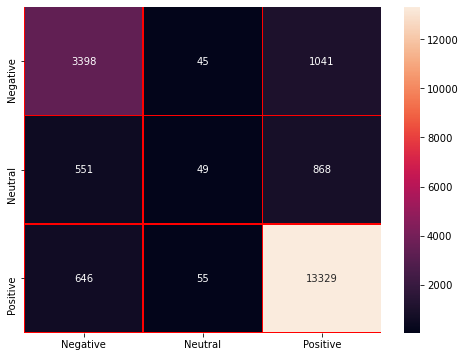

In [60]:
cm1 = confusion_matrix(Y_test,pred1)
side_bar = ["Negative","Neutral","Positive"]

f, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm1,annot =True, linewidth=.5, linecolor="r", fmt=".0f", ax = ax)

ax.set_xticklabels(side_bar)
ax.set_yticklabels(side_bar)
plt.show()

In [61]:
#pickle.dump(tc1, open("ml_lg.pkl",'wb'))

In [62]:
#with open('ml_lg.pkl', 'rb') as f:
    #model = pickle.load(f)

In [63]:
df3 = pd.DataFrame({'Actual': Y_test, 'Predicted': pred1})
df3

,Actual,Predicted
0,2,2
1,2,2
2,2,2
3,1,0
4,0,0
...,...,...
19977,2,2
19978,1,2
19979,0,0
19980,2,0


In [64]:
print("Test accuracy of Logistic reg: ",tc1.score(X_test,Y_test))

Test accuracy of Logistic reg:  0.839555600040036


# Random Forest

In [65]:
from sklearn.ensemble import RandomForestClassifier

tc2 = RandomForestClassifier(n_estimators=100, random_state=0)
tc2.fit(X_train, Y_train)

RandomForestClassifier(random_state=0)

In [66]:
pred2 = tc2.predict(X_test)

In [67]:
print(confusion_matrix(Y_test,pred2))
print(classification_report(Y_test,pred2))
print(accuracy_score(Y_test, pred2))

[[ 3378    18  1088]
 [  574    12   882]
 [  868    27 13135]]
              precision    recall  f1-score   support

           0       0.70      0.75      0.73      4484
           1       0.21      0.01      0.02      1468
           2       0.87      0.94      0.90     14030

    accuracy                           0.83     19982
   macro avg       0.59      0.57      0.55     19982
weighted avg       0.78      0.83      0.80     19982

0.8269942948653788


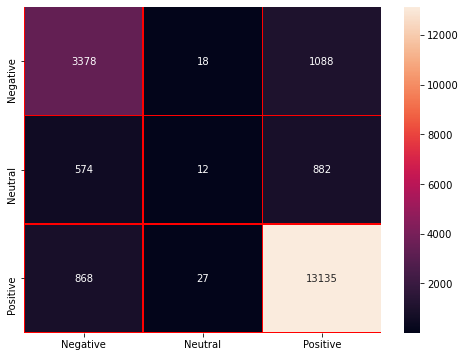

In [68]:
cm2 = confusion_matrix(Y_test,pred2)
side_bar = ["Negative","Neutral","Positive"]

f, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm2,annot =True, linewidth=.5, linecolor="r", fmt=".0f", ax = ax)

ax.set_xticklabels(side_bar)
ax.set_yticklabels(side_bar)
plt.show()

In [69]:
print(f1_score(Y_test,pred2,average=None))

[0.72613929 0.0157377  0.90166466]


In [70]:
print(precision_score(Y_test,pred2,average="weighted"))

0.7832937500399734


In [71]:
df4 = pd.DataFrame({'Actual': Y_test, 'Predicted': pred2})
df4

,Actual,Predicted
0,2,2
1,2,2
2,2,2
3,1,2
4,0,2
...,...,...
19977,2,2
19978,1,2
19979,0,0
19980,2,0


# SVM

In [72]:
from sklearn.svm import SVC

#from sklearn.svm import LinearSVC
#tc5 = LinearSVC()

tc3 = SVC(kernel='linear')
tc3.fit(X_train, Y_train)

SVC(kernel='linear')

In [73]:
pred3 = tc3.predict(X_test)

In [74]:
print(confusion_matrix(Y_test,pred3))
print(classification_report(Y_test,pred3))
print(accuracy_score(Y_test, pred3))

[[ 3453     0  1031]
 [  585     0   883]
 [  707     3 13320]]
              precision    recall  f1-score   support

           0       0.73      0.77      0.75      4484
           1       0.00      0.00      0.00      1468
           2       0.87      0.95      0.91     14030

    accuracy                           0.84     19982
   macro avg       0.53      0.57      0.55     19982
weighted avg       0.78      0.84      0.81     19982

0.8394054649184266


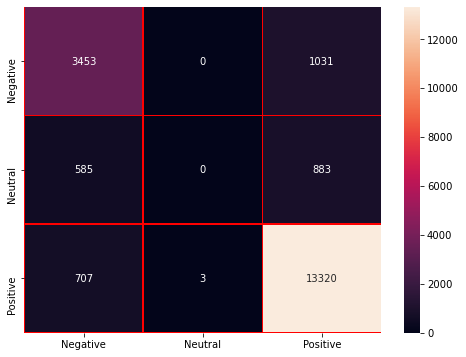

In [76]:
cm3 = confusion_matrix(Y_test,pred3)
side_bar = ["Negative","Neutral","Positive"]

f, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm3,annot =True, linewidth=.5, linecolor="r", fmt=".0f", ax = ax)

ax.set_xticklabels(side_bar)
ax.set_yticklabels(side_bar)
plt.show()

In [77]:
print(f1_score(Y_test,pred3,average=None))

[0.74829342 0.         0.91033352]


In [78]:
print(precision_score(Y_test,pred3,average="weighted"))

0.7772163640343076


In [79]:
df7 = pd.DataFrame({'Actual': Y_test, 'Predicted': pred3})
df7

,Actual,Predicted
0,2,2
1,2,2
2,2,2
3,1,0
4,0,0
...,...,...
19977,2,2
19978,1,2
19979,0,0
19980,2,0


# XGBoost

In [80]:
!pip install xgboost

In [81]:
from xgboost import XGBClassifier 

tc4 = XGBClassifier (n_estimators=150, seed=123)
tc4.fit(X_train, Y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0, gpu_id=-1,
              importance_type='gain', interaction_constraints='',
              learning_rate=0.300000012, max_delta_step=0, max_depth=6,
              min_child_weight=1, missing=nan, monotone_constraints='()',
              n_estimators=150, n_jobs=0, num_parallel_tree=1,
              objective='multi:softprob', random_state=123, reg_alpha=0,
              reg_lambda=1, scale_pos_weight=None, seed=123, subsample=1,
              tree_method='exact', validate_parameters=1, verbosity=None)

In [85]:
pred4 = tc4.predict(X_test)

In [86]:
print(confusion_matrix(Y_test,pred4))
print(classification_report(Y_test,pred4))
print(accuracy_score(Y_test, pred4))
#print("Accuracy: %.2f%%" % (accuracy * 100.0))

[[ 3046    50  1388]
 [  479    36   953]
 [  538    44 13448]]
              precision    recall  f1-score   support

           0       0.75      0.68      0.71      4484
           1       0.28      0.02      0.05      1468
           2       0.85      0.96      0.90     14030

    accuracy                           0.83     19982
   macro avg       0.63      0.55      0.55     19982
weighted avg       0.79      0.83      0.80     19982

0.8272445200680613


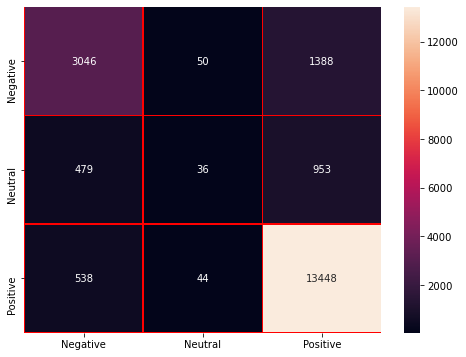

In [87]:
cm4 = confusion_matrix(Y_test,pred4)
side_bar = ["Negative","Neutral","Positive"]

f, ax = plt.subplots(figsize=(8,6))
sns.heatmap(cm4,annot =True, linewidth=.5, linecolor="r", fmt=".0f", ax = ax)

ax.set_xticklabels(side_bar)
ax.set_yticklabels(side_bar)
plt.show()

In [88]:
print(f1_score(Y_test,pred4,average=None))

[0.71276471 0.04505632 0.90197525]


In [89]:
print(precision_score(Y_test,pred4,average="micro"))

0.8272445200680613
